# Time-Resolved Decision Predictability

Analyses how well the BunDLe-Net latent space predicts the upcoming choice
as a function of **normalised position within the decision-strict trial interval**.

- **x-axis**: normalised decision-strict interval time  
  `0.0` = immediately after the previous choice (start of the window)  
  `1.0` = the current choice boundary (end of the window)
- **y-axis**: logistic-regression decoding accuracy (left vs right)

Phases:
- **Phase 0** — Path diagnostic: verify saved latent shapes for both candidate runs
- **Phase 1** — Load per-window arrays, inspect label distribution
- **Phase 2** — Verify latent shape (recompute only if absent)
- **Phase 3** — Fit LogisticRegression decoder, validate against reference accuracy
- **Phase 4** — Compute within-trial normalised time
- **Phase 5** — Figures and save
- **Phase 6** — Trial / `metrics.json` alignment diagnostic

In [1]:
from pathlib import Path
import datetime
import json
import warnings
warnings.filterwarnings('ignore', category=FutureWarning)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, balanced_accuracy_score

# Navigate to repo root if the notebook is run from demos/
REPO_ROOT = Path.cwd()
if REPO_ROOT.name == 'demos':
    REPO_ROOT = REPO_ROOT.parent

# ── Candidate run directories ────────────────────────────────────────────────
DISCRETE_RUN_DIR = REPO_ROOT / (
    'results/grid_search_20260519_013618_same_partition_decision_strict_discrete_only'
    '/run_20260519_013620'
)
HYBRID_RUN_DIR = REPO_ROOT / (
    'results/grid_search_20260518_221010_same_partition_decision_strict_alpha_050_070_090'
    '/grid_search_20260518_221026'
    '/run_000_data_path=JPAS_0023_20230922_downsample_fs=30_downsample_method=gaussian'
    '_good_neurons_only=False_apply_hold_tra_64b61128'
)
DATASET_PATH = REPO_ROOT / 'datasets/raw/twoArmBandit/JPAS_0023_20230922'

# ── Timestamped output directory ─────────────────────────────────────────────
_ts = datetime.datetime.now().strftime('%Y%m%d_%H%M%S')
OUTPUT_DIR = REPO_ROOT / f'results/analysis/time_resolved_predictability_{_ts}'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print(f'REPO_ROOT:        {REPO_ROOT}')
print(f'DISCRETE_RUN_DIR: {DISCRETE_RUN_DIR}')
print(f'HYBRID_RUN_DIR:   {HYBRID_RUN_DIR}')
print(f'OUTPUT_DIR:       {OUTPUT_DIR}')

REPO_ROOT:        /home/kerim/Projects/Neural Algorithms/NC-MCM
DISCRETE_RUN_DIR: /home/kerim/Projects/Neural Algorithms/NC-MCM/results/grid_search_20260519_013618_same_partition_decision_strict_discrete_only/run_20260519_013620
HYBRID_RUN_DIR:   /home/kerim/Projects/Neural Algorithms/NC-MCM/results/grid_search_20260518_221010_same_partition_decision_strict_alpha_050_070_090/grid_search_20260518_221026/run_000_data_path=JPAS_0023_20230922_downsample_fs=30_downsample_method=gaussian_good_neurons_only=False_apply_hold_tra_64b61128
OUTPUT_DIR:       /home/kerim/Projects/Neural Algorithms/NC-MCM/results/analysis/time_resolved_predictability_20260519_023921


## Phase 0 — Path diagnostic

List every `.npy` file under `<run>/data/` for both candidate runs and verify that
`latent_trajectories_*.npy` has shape `(n_windows, 3)`.

In [2]:
def _check_run(run_dir, label):
    print(f'\n{"+"*62}')
    print(f'  {label}')
    print(f'  {run_dir}')
    data_dir = run_dir / 'data'
    if not data_dir.exists():
        print('  !!  data/ directory NOT FOUND')
        return False
    npy_files = sorted(data_dir.glob('*.npy'))
    print(f'\n  .npy files ({len(npy_files)} total):')
    valid = True
    for f in npy_files:
        arr = np.load(f, mmap_mode='r')
        note = ''
        if 'latent_trajectories' in f.name:
            if arr.ndim == 2 and arr.shape[1] == 3:
                note = '  <- valid latents'
            else:
                note = f'  !! ANOMALOUS (expected (n,3), got {arr.shape})'
                valid = False
        print(f'    {f.name:55s} {str(arr.shape):20s} {arr.dtype}{note}')
    return valid

disc_ok = _check_run(DISCRETE_RUN_DIR, 'DISCRETE-ONLY RUN')
hyb_ok  = _check_run(HYBRID_RUN_DIR,   'HYBRID RUN')

print(f'\nDiscrete-only latents valid: {disc_ok}')
print(f'Hybrid latents valid:        {hyb_ok}')


++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
  DISCRETE-ONLY RUN
  /home/kerim/Projects/Neural Algorithms/NC-MCM/results/grid_search_20260519_013618_same_partition_decision_strict_discrete_only/run_20260519_013620

  .npy files (14 total):
    behaviour_labels_train.npy                              (29534,)             int64
    behaviour_labels_validation.npy                         (6210,)              int64
    cont_loss_array.npy                                     (500,)               float64
    cont_test_loss_array.npy                                (500,)               float64
    disc_loss_array.npy                                     (500,)               float64
    disc_test_loss_array.npy                                (500,)               float64
    hgf_beliefs.npy                                         (38794,)             float32
    latent_trajectories_train.npy                           (29534, 3)           float32  <- valid latents
    latent_traj

In [3]:
# Select the primary run: prefer the hybrid run (alpha=0.5, b_type=hybrid)
if hyb_ok:
    RUN_DIR = HYBRID_RUN_DIR
    print('Selected: HYBRID RUN (b_type=hybrid, alpha=0.5)')
elif disc_ok:
    RUN_DIR = DISCRETE_RUN_DIR
    print('Selected: DISCRETE-ONLY RUN (fallback)')
else:
    raise RuntimeError(
        'Neither run folder contains valid (n_windows, 3) latent trajectories. '
        'Recomputation required — see plan Phase 2 in /memories/session/plan.md.'
    )

DATA_DIR = RUN_DIR / 'data'

config      = json.load(open(RUN_DIR / 'config.json'))
dec_summary = json.load(open(DATA_DIR / 'decoding/decoding_summary.json'))

print(f'\nConfig (relevant keys):')
for k in ['b_type', 'b_mode', 'b_labels', 'n_classes', 'window', 'latent_dim',
          'alpha', 'context_policy', 'trial_random_state', 'trial_test_ratio',
          'downsample_fs']:
    print(f'  {k}: {config.get(k, "<missing>")}')

ref_acc = dec_summary['metrics']['discrete']['unweighted_val_acc']
print(f'\nReference discrete unweighted_val_acc: {ref_acc:.4f}')

Selected: HYBRID RUN (b_type=hybrid, alpha=0.5)

Config (relevant keys):
  b_type: hybrid
  b_mode: decision_strict
  b_labels: ['choosing left', 'choosing right']
  n_classes: 2
  window: 50
  latent_dim: 3
  alpha: 0.5
  context_policy: same_partition
  trial_random_state: 42
  trial_test_ratio: 0.2
  downsample_fs: 30

Reference discrete unweighted_val_acc: 0.8102


## Phase 1 — Load per-window arrays

Load all saved arrays and inspect the label distribution.
Per the config, `b_labels = ['choosing left', 'choosing right']`,
so labels **0** and **1** are both valid decision classes — do not filter label 0.

In [4]:
lat_train = np.load(DATA_DIR / 'latent_trajectories_train.npy')
lat_val   = np.load(DATA_DIR / 'latent_trajectories_validation.npy')
b_train   = np.load(DATA_DIR / 'behaviour_labels_train.npy')
b_val     = np.load(DATA_DIR / 'behaviour_labels_validation.npy')
tid_train = np.load(DATA_DIR / 'trial_ids_train.npy')
tid_val   = np.load(DATA_DIR / 'trial_ids_validation.npy')
trial_start_indices = np.load(DATA_DIR / 'trial_start_indices.npy')

_hgf_tr = DATA_DIR / 'hgf_belief_train.npy'
_hgf_va = DATA_DIR / 'hgf_belief_validation.npy'
hgf_train = np.load(_hgf_tr).flatten() if _hgf_tr.exists() else None
hgf_val   = np.load(_hgf_va).flatten() if _hgf_va.exists() else None

print('Loaded arrays:')
print(f'  lat_train:            {lat_train.shape}  {lat_train.dtype}')
print(f'  lat_val:              {lat_val.shape}  {lat_val.dtype}')
print(f'  b_train:              {b_train.shape}  {b_train.dtype}')
print(f'  b_val:                {b_val.shape}  {b_val.dtype}')
print(f'  tid_train:            {tid_train.shape}  {tid_train.dtype}')
print(f'  tid_val:              {tid_val.shape}  {tid_val.dtype}')
print(f'  trial_start_indices:  {trial_start_indices.shape}  {trial_start_indices.dtype}')
if hgf_train is not None:
    print(f'  hgf_belief_train:     {hgf_train.shape}  {hgf_train.dtype}')
    print(f'  hgf_belief_val:       {hgf_val.shape}  {hgf_val.dtype}')

Loaded arrays:
  lat_train:            (29534, 3)  float32
  lat_val:              (6210, 3)  float32
  b_train:              (29534,)  int64
  b_val:                (6210,)  int64
  tid_train:            (29534,)  int64
  tid_val:              (6210,)  int64
  trial_start_indices:  (237,)  int64
  hgf_belief_train:     (29534,)  float32
  hgf_belief_val:       (6210,)  float32


In [5]:
b_labels = config['b_labels']  # e.g. ['choosing left', 'choosing right']
print(f"config['b_labels'] = {b_labels}")
print(f"config['n_classes'] = {config['n_classes']}")

print('\nValidation label distribution:')
vals, cts = np.unique(b_val, return_counts=True)
for v, c in zip(vals, cts):
    name = b_labels[v] if v < len(b_labels) else f'UNEXPECTED({v})'
    print(f'  label {v} = "{name}": {c} windows ({c / len(b_val) * 100:.1f}%)')

unexpected = [v for v in vals if v >= len(b_labels)]
if unexpected:
    print(f'\n!!  UNEXPECTED labels found: {unexpected}. Investigate before fitting decoder.')
else:
    print('\n-> All labels are expected valid classes.')

print(f'\nTrial counts:')
n_train_trials = len(np.unique(tid_train))
n_val_trials   = len(np.unique(tid_val))
n_run_trials   = n_train_trials + n_val_trials
print(f'  unique train trials:             {n_train_trials}')
print(f'  unique val trials:               {n_val_trials}')
print(f'  total run trials:                {n_run_trials}')
print(f'  trial_start_indices length:      {len(trial_start_indices)}')
print(f'  trial_ids_train range: [{int(tid_train.min())}, {int(tid_train.max())}]')
print(f'  trial_ids_val range:   [{int(tid_val.min())}, {int(tid_val.max())}]')

config['b_labels'] = ['choosing left', 'choosing right']
config['n_classes'] = 2

Validation label distribution:
  label 0 = "choosing left": 2700 windows (43.5%)
  label 1 = "choosing right": 3510 windows (56.5%)

-> All labels are expected valid classes.

Trial counts:
  unique train trials:             190
  unique val trials:               47
  total run trials:                237
  trial_start_indices length:      237
  trial_ids_train range: [0, 236]
  trial_ids_val range:   [6, 235]


## Phase 2 — Verify latent shape

Check that `latent_trajectories_*.npy` has the expected shape `(n_windows, latent_dim=3)`.  
If shapes are valid, no recomputation is needed.

In [6]:
latent_dim = config['latent_dim']

print('Latent trajectory shapes:')
print(f'  lat_train: {lat_train.shape}  (expected ({len(b_train)}, {latent_dim}))')
print(f'  lat_val:   {lat_val.shape}  (expected ({len(b_val)}, {latent_dim}))')

assert lat_train.ndim == 2 and lat_train.shape[1] == latent_dim, (
    f'lat_train shape {lat_train.shape} is not (n_windows, {latent_dim})'
)
assert lat_val.ndim == 2 and lat_val.shape[1] == latent_dim, (
    f'lat_val shape {lat_val.shape} is not (n_windows, {latent_dim})'
)
assert lat_train.shape[0] == len(b_train), (
    f'Shape mismatch: lat_train n_rows {lat_train.shape[0]} != b_train {len(b_train)}'
)
assert lat_val.shape[0] == len(b_val), (
    f'Shape mismatch: lat_val n_rows {lat_val.shape[0]} != b_val {len(b_val)}'
)

print('\n-> Latent shapes valid. No recomputation needed.')

Latent trajectory shapes:
  lat_train: (29534, 3)  (expected (29534, 3))
  lat_val:   (6210, 3)  (expected (6210, 3))

-> Latent shapes valid. No recomputation needed.


## Phase 3 — Decoder

Fit a `LogisticRegression` on the train latents and evaluate on the validation set.  
Reference accuracy from the saved decoding run: ~0.810 (unweighted).

In [7]:
clf = LogisticRegression(max_iter=500, C=1.0, random_state=42)
clf.fit(lat_train, b_train)

val_probs   = clf.predict_proba(lat_val)          # (n_val_windows, n_classes)
val_preds   = clf.predict(lat_val)
val_correct = (val_preds == b_val).astype(int)
val_acc     = accuracy_score(b_val, val_preds)
val_bal_acc = balanced_accuracy_score(b_val, val_preds)

print(f'Decoder validation accuracy:     {val_acc:.4f}')
print(f'Balanced accuracy:               {val_bal_acc:.4f}')
print(f'Reference unweighted_val_acc:    {ref_acc:.4f}')

delta = abs(val_acc - ref_acc)
if delta > 0.02:
    print(f'\n!!  val_acc deviates {delta:.4f} from reference (>{0.02:.2f}). Investigate.')
else:
    print(f'\n-> val_acc within {delta:.4f} of reference.')

print('\nPer-class accuracy (val):')
for v, name in enumerate(b_labels):
    mask = b_val == v
    if mask.sum() == 0:
        continue
    acc_v = val_correct[mask].mean()
    print(f'  label {v} = "{name}": {acc_v:.4f}  (n={mask.sum()})')

Decoder validation accuracy:     0.8111
Balanced accuracy:               0.8076
Reference unweighted_val_acc:    0.8102

-> val_acc within 0.0009 of reference.

Per-class accuracy (val):
  label 0 = "choosing left": 0.7807  (n=2700)
  label 1 = "choosing right": 0.8345  (n=3510)


## Phase 4 — Within-trial normalised time

Assign each validation window its position within its trial.  
Windows from `prep_data_trials` are already in temporal order within each trial.

$$\text{normalised\_time} = \frac{\text{within\_trial\_idx}}{\max(n_{\text{windows\_in\_trial}} - 1,\; 1)}$$

So the **first** window gets `0.0` and the **last** window gets `1.0`.

In [8]:
df_val = pd.DataFrame({
    'y0':       lat_val[:, 0],
    'y1':       lat_val[:, 1],
    'y2':       lat_val[:, 2],
    'label':    b_val.astype(int),
    'trial_id': tid_val.astype(int),
    'correct':  val_correct,
    'pred':     val_preds.astype(int),
    'p_class0': val_probs[:, 0],
    'p_class1': val_probs[:, 1],
})
if hgf_val is not None:
    df_val['hgf'] = hgf_val

df_val['choice_label'] = df_val['label'].map(
    {i: name for i, name in enumerate(b_labels)}
)

# Within-trial window index (temporal order is preserved from prep_data_trials)
df_val['within_trial_idx'] = df_val.groupby('trial_id').cumcount()

# n_windows_in_trial - 1 as denominator so the last window reaches exactly 1.0
n_windows_max = df_val.groupby('trial_id')['within_trial_idx'].transform('max')
df_val['normalized_time'] = df_val['within_trial_idx'] / n_windows_max.clip(lower=1)

print(f'df_val rows:           {len(df_val)}')
print(f'Unique val trials:     {df_val["trial_id"].nunique()}')
print(f'normalized_time range: [{df_val["normalized_time"].min():.3f}, '
      f'{df_val["normalized_time"].max():.3f}]')

windows_per_trial = df_val.groupby('trial_id').size()
print(f'\nWindows per trial:  min={windows_per_trial.min()}  '
      f'median={windows_per_trial.median():.0f}  '
      f'max={windows_per_trial.max()}')

print(f'\nFirst 5 rows:')
print(df_val[['trial_id', 'within_trial_idx', 'normalized_time',
              'label', 'choice_label', 'correct']].head())

df_val rows:           6210
Unique val trials:     47
normalized_time range: [0.000, 1.000]

Windows per trial:  min=41  median=109  max=437

First 5 rows:
   trial_id  within_trial_idx  normalized_time  label    choice_label  correct
0         6                 0         0.000000      1  choosing right        0
1         6                 1         0.004739      1  choosing right        0
2         6                 2         0.009479      1  choosing right        0
3         6                 3         0.014218      1  choosing right        0
4         6                 4         0.018957      1  choosing right        0


## Phase 5 — Figures

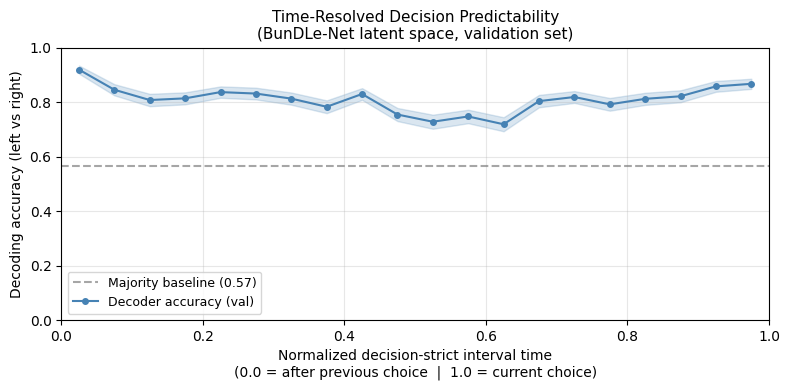

Saved -> /home/kerim/Projects/Neural Algorithms/NC-MCM/results/analysis/time_resolved_predictability_20260519_023921/accuracy_over_decision_strict_time.png


In [9]:
# Figure 1: accuracy vs normalised decision-strict interval time
N_BINS    = 20
bin_edges = np.linspace(0, 1, N_BINS + 1)
bin_ctrs  = (bin_edges[:-1] + bin_edges[1:]) / 2

bin_idx = pd.cut(df_val['normalized_time'], bins=bin_edges,
                 labels=False, include_lowest=True)

bin_acc, bin_sem, bin_n = [], [], []
for b_i in range(N_BINS):
    mask = bin_idx == b_i
    if not mask.any():
        bin_acc.append(np.nan); bin_sem.append(np.nan); bin_n.append(0)
    else:
        c = df_val['correct'].values[mask]
        bin_acc.append(c.mean())
        bin_sem.append(stats.sem(c))
        bin_n.append(mask.sum())

bin_acc = np.array(bin_acc)
bin_sem = np.array(bin_sem)
chance  = len(b_val[b_val == 1]) / len(b_val)   # majority-class baseline

fig, ax = plt.subplots(figsize=(8, 4))
ax.axhline(chance, color='grey', linestyle='--', alpha=0.7,
           label=f'Majority baseline ({chance:.2f})')
ax.fill_between(bin_ctrs, bin_acc - bin_sem, bin_acc + bin_sem,
                alpha=0.2, color='steelblue')
ax.plot(bin_ctrs, bin_acc, '-o', color='steelblue', markersize=4,
        label='Decoder accuracy (val)')
ax.set_xlabel(
    'Normalized decision-strict interval time\n'
    '(0.0 = after previous choice  |  1.0 = current choice)',
    fontsize=10
)
ax.set_ylabel('Decoding accuracy (left vs right)', fontsize=10)
ax.set_title(
    'Time-Resolved Decision Predictability\n'
    '(BunDLe-Net latent space, validation set)',
    fontsize=11
)
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / 'accuracy_over_decision_strict_time.png', dpi=150)
plt.show()
print(f'Saved -> {OUTPUT_DIR / "accuracy_over_decision_strict_time.png"}')

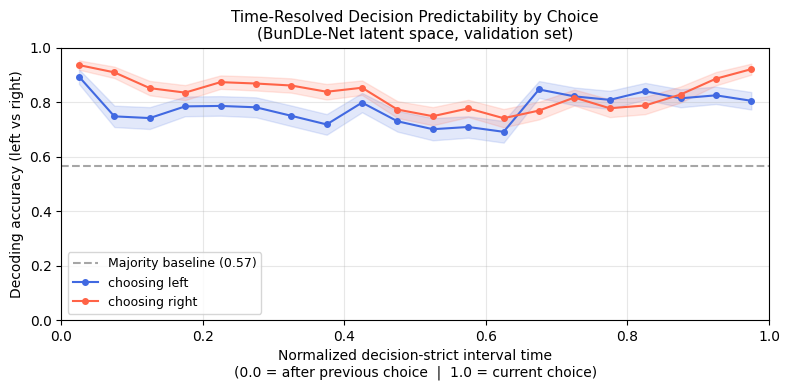

Saved -> /home/kerim/Projects/Neural Algorithms/NC-MCM/results/analysis/time_resolved_predictability_20260519_023921/accuracy_over_decision_strict_time_by_choice.png


In [10]:
# Figure 2: accuracy vs normalised time, split by choice
CHOICE_COLORS = {
    b_labels[0]: 'royalblue',
    b_labels[1]: 'tomato',
}

fig, ax = plt.subplots(figsize=(8, 4))
ax.axhline(chance, color='grey', linestyle='--', alpha=0.7,
           label=f'Majority baseline ({chance:.2f})')

for choice_name, color in CHOICE_COLORS.items():
    sub     = df_val[df_val['choice_label'] == choice_name]
    sub_idx = pd.cut(sub['normalized_time'], bins=bin_edges,
                     labels=False, include_lowest=True)
    acc_c, sem_c = [], []
    for b_i in range(N_BINS):
        mask = sub_idx == b_i
        if not mask.any():
            acc_c.append(np.nan); sem_c.append(np.nan)
        else:
            c = sub['correct'].values[mask]
            acc_c.append(c.mean())
            sem_c.append(stats.sem(c))
    acc_c = np.array(acc_c)
    sem_c = np.array(sem_c)
    ax.fill_between(bin_ctrs, acc_c - sem_c, acc_c + sem_c,
                    alpha=0.15, color=color)
    ax.plot(bin_ctrs, acc_c, '-o', color=color, markersize=4,
            label=choice_name)

ax.set_xlabel(
    'Normalized decision-strict interval time\n'
    '(0.0 = after previous choice  |  1.0 = current choice)',
    fontsize=10
)
ax.set_ylabel('Decoding accuracy (left vs right)', fontsize=10)
ax.set_title(
    'Time-Resolved Decision Predictability by Choice\n'
    '(BunDLe-Net latent space, validation set)',
    fontsize=11
)
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / 'accuracy_over_decision_strict_time_by_choice.png', dpi=150)
plt.show()
print(f'Saved -> {OUTPUT_DIR / "accuracy_over_decision_strict_time_by_choice.png"}')

In [11]:
# Save prediction table
save_cols = ['trial_id', 'within_trial_idx', 'normalized_time',
             'label', 'choice_label', 'correct', 'pred', 'p_class0', 'p_class1']
if 'hgf' in df_val.columns:
    save_cols.append('hgf')
df_val[save_cols].to_csv(OUTPUT_DIR / 'validation_prediction_table.csv', index=False)

# Save summary JSON
summary = {
    'run_dir':          str(RUN_DIR),
    'b_type':           config['b_type'],
    'b_mode':           config['b_mode'],
    'timestamp':        _ts,
    'n_train_windows':  int(len(b_train)),
    'n_val_windows':    int(len(b_val)),
    'n_train_trials':   int(n_train_trials),
    'n_val_trials':     int(n_val_trials),
    'n_run_trials':     int(n_run_trials),
    'val_acc':          float(val_acc),
    'val_balanced_acc': float(val_bal_acc),
    'ref_val_acc':      float(ref_acc),
    'b_labels':         b_labels,
    'val_label_dist':   {
        str(int(v)): int(c)
        for v, c in zip(*np.unique(b_val, return_counts=True))
    },
    'n_time_bins':      N_BINS,
}
with open(OUTPUT_DIR / 'summary.json', 'w') as f:
    json.dump(summary, f, indent=2)

print(f'Outputs saved to: {OUTPUT_DIR}')
for name in ['accuracy_over_decision_strict_time.png',
             'accuracy_over_decision_strict_time_by_choice.png',
             'validation_prediction_table.csv',
             'summary.json']:
    print(f'  {name}')

Outputs saved to: /home/kerim/Projects/Neural Algorithms/NC-MCM/results/analysis/time_resolved_predictability_20260519_023921
  accuracy_over_decision_strict_time.png
  accuracy_over_decision_strict_time_by_choice.png
  validation_prediction_table.csv
  summary.json


## Phase 6 — Trial / `metrics.json` alignment diagnostic

Compare the 237 run trials (`trial_start_indices.npy`) with the 258 entries in
`metrics.json`. The run trial IDs span `[0, 236]` but `metrics.json` has 258 entries;
some behavioral trials were not covered by the neural recording.

**Rule**: the 237 run trial IDs are **not** assumed to be the first 237 entries of
`metrics.json`. Identity mapping (`trial_id == metrics_index`) is treated as a
hypothesis and verified by checking temporal ordering consistency.

In [12]:
METRICS_PATH = DATASET_PATH / 'metrics.json'
with open(METRICS_PATH) as f:
    metrics_data = json.load(f)
raw_trials = metrics_data.get('metrics', metrics_data).get('trials', [])

# Run trial IDs (the trials actually used in the BunDLe-Net run)
run_trial_ids = sorted(
    set(int(x) for x in tid_train) | set(int(x) for x in tid_val)
)

print('=== Trial count summary ===')
print(f'  trial_start_indices.npy entries:  {len(trial_start_indices)}')
print(f'  metrics.json trials:              {len(raw_trials)}')
print(f'  run trial IDs used:               {len(run_trial_ids)}')
print(f'    range: [{run_trial_ids[0]}, {run_trial_ids[-1]}]')
print(f'    contiguous [0..{len(run_trial_ids)-1}]: '
      f'{run_trial_ids == list(range(len(run_trial_ids)))}')
print()

n_extra = len(raw_trials) - len(trial_start_indices)
if n_extra > 0:
    print(f'metrics.json has {n_extra} more entries than trial_start_indices.')
    print('These extra behavioral trials likely fall outside the neural recording window.')
elif n_extra == 0:
    print('trial_start_indices and metrics.json have equal length.')
else:
    print(f'!! trial_start_indices has {-n_extra} MORE entries than metrics.json. Unexpected.')

print()
all_in_bounds = max(run_trial_ids) < len(raw_trials)
print(f'All run_trial_ids within metrics.json bounds: {all_in_bounds}')
if not all_in_bounds:
    oob = [i for i in run_trial_ids if i >= len(raw_trials)]
    print(f'  Out-of-bounds IDs: {oob[:10]} ...')

=== Trial count summary ===
  trial_start_indices.npy entries:  237
  metrics.json trials:              258
  run trial IDs used:               237
    range: [0, 236]
    contiguous [0..236]: True

metrics.json has 21 more entries than trial_start_indices.
These extra behavioral trials likely fall outside the neural recording window.

All run_trial_ids within metrics.json bounds: True


In [16]:
# ── Phase 6b: time-based identity-mapping check ─────────────────────────────
# ds already loaded in Phase 6a above; behavioral_time is the trimmed ms array
behavioral_time = ds.behavioral_time          # ms, shape (T,)
ds_trial_indices = ds.trial_indices           # per-sample trial index (0..N-1 or -1)

# ── Step 1: look up the metrics trial index for each dataset trial ────────────
# _create_trial_indices assigns a metrics-sorted index to each neural sample;
# _build_trial_start_indices just records WHERE each trial starts (ignores value).
# So: metrics_idx_k = ds.trial_indices[trial_start_indices[k]]
# is the exact sorted-trials position that the dataset uses for trial k.
metrics_idx_for_k = ds_trial_indices[trial_start_indices[run_trial_ids]]  # shape (237,)

print("=== Phase 6b: exact metrics-trial mapping ===")
print(f"trial_start_indices (first 5): {trial_start_indices[:5].tolist()}")
print(f"metrics_idx_for_k  (first 5): {metrics_idx_for_k[:5].tolist()}")
print(f"metrics_idx_for_k range: [{metrics_idx_for_k.min()}, {metrics_idx_for_k.max()}]")

# Check if identity mapping holds (metrics_idx_for_k[i] == run_trial_ids[i])
identity_ok = bool(np.all(metrics_idx_for_k == np.array(run_trial_ids)))
print(f"\nIdentity mapping (metrics_idx == run_trial_id)? {identity_ok}")
if not identity_ok:
    mismatches = np.where(metrics_idx_for_k != np.array(run_trial_ids))[0]
    print(f"  {len(mismatches)} mismatches; first 10:")
    for i in mismatches[:10]:
        print(f"    dataset trial {run_trial_ids[i]}  →  metrics_idx {metrics_idx_for_k[i]}")

# ── Step 2: build aligned offset using exact mapping ─────────────────────────
# Sort all metrics trials exactly as _create_trial_indices does
sorted_all_trials = sorted(raw_trials, key=lambda t: t.get('start', 0))
print(f"\nsorted_all_trials length (all, incl. start=None): {len(sorted_all_trials)}")

# For each dataset trial k, get the correct metrics start time
correct_start_ms = []
valid_mask = []
for k_pos, mi in enumerate(metrics_idx_for_k):
    t = sorted_all_trials[mi]
    s = t.get('start')
    if s is not None:
        correct_start_ms.append(float(s))
        valid_mask.append(True)
    else:
        correct_start_ms.append(np.nan)
        valid_mask.append(False)
correct_start_ms = np.array(correct_start_ms)
valid_mask       = np.array(valid_mask)

n_no_start = int((~valid_mask).sum())
if n_no_start:
    print(f"⚠  {n_no_start} dataset trials map to metrics entries with start=None — excluded from offset check.")

run_beh_ms = behavioral_time[trial_start_indices[run_trial_ids]]
offsets = correct_start_ms[valid_mask] - run_beh_ms[valid_mask]

median_offset = float(np.median(offsets))
mad_offset    = float(np.median(np.abs(offsets - median_offset)))
outlier_mask2 = np.abs(offsets - median_offset) > 3 * max(mad_offset, 1)
n_out2        = int(outlier_mask2.sum())

# Ordering check on inliers
inlier_sel = ~outlier_mask2
if inlier_sel.sum() > 1:
    inlier_beh = run_beh_ms[valid_mask][inlier_sel]
    inlier_raw = correct_start_ms[valid_mask][inlier_sel]
    order_ok   = bool(np.all(np.diff(inlier_beh) > 0) and np.all(np.diff(inlier_raw) > 0))
else:
    order_ok = True

print()
print("=== Time-based alignment check (exact mapping via ds.trial_indices) ===")
print("Method: behavioral_time[trial_start_indices[k]]  vs  sorted_all_trials[metrics_idx_for_k]['start']")
print(f"Offset (correct_raw_ms − behavioral_ms) — {offsets.size} valid trials:")
print(f"  mean:   {offsets.mean():8.1f} ms")
print(f"  std:    {offsets.std():8.1f} ms")
print(f"  median: {median_offset:8.1f} ms")
print(f"  MAD:    {mad_offset:8.1f} ms")
print(f"  min:    {offsets.min():8.1f} ms")
print(f"  max:    {offsets.max():8.1f} ms")
print(f"Outliers (|offset − median| > 3·MAD): {n_out2}")
if n_out2:
    out2_idx = np.where(outlier_mask2)[0][:10]
    rids2    = [run_trial_ids[i] for i in np.where(valid_mask)[0][out2_idx]]
    print(f"  Outlier run_trial_ids: {rids2}")
print(f"Temporal ordering preserved (inliers): {order_ok}")

# Preview
valid_indices_in_run = np.where(valid_mask)[0][:10]
preview = pd.DataFrame({
    "run_trial_id":  [run_trial_ids[i]            for i in valid_indices_in_run],
    "metrics_idx":   [int(metrics_idx_for_k[i])   for i in valid_indices_in_run],
    "behavioral_ms": run_beh_ms[valid_indices_in_run].round(0).astype(int),
    "raw_start_ms":  correct_start_ms[valid_indices_in_run].astype(int),
    "offset_ms":     (correct_start_ms[valid_indices_in_run] - run_beh_ms[valid_indices_in_run]).round(1),
    "raw_choice":    [sorted_all_trials[int(metrics_idx_for_k[i])].get("choice", "?")
                      for i in valid_indices_in_run],
})
print("\nPreview (first 10 valid run trials with exact mapping):")
print(preview.to_string(index=False))
print()

CONSISTENT = (mad_offset < 500) and (abs(median_offset) < 2000) and order_ok
if CONSISTENT:
    print("-> Identity mapping is CONSISTENT (after correct metrics-index lookup).")
    print(f"   Typical offset: {median_offset:.1f} ms (MAD={mad_offset:.1f} ms).")
    print("   The offset ≈ one downsampled frame (≤ 33 ms at 30 Hz) — as expected.")
    if n_out2:
        print(f"   {n_out2} outlier trial(s) — likely very short or anomalous trials.")
else:
    print("!! BLOCKER: Alignment NOT consistent even with exact mapping.")
    print(f"   Median offset={median_offset:.1f} ms, MAD={mad_offset:.1f} ms, order_ok={order_ok}.")
    print("   Do NOT use metrics.json annotations until alignment is clarified.")


=== Phase 6b: exact metrics-trial mapping ===
trial_start_indices (first 5): [0, 91, 318, 538, 788]
metrics_idx_for_k  (first 5): [0, 1, 2, 3, 4]
metrics_idx_for_k range: [0, 240]

Identity mapping (metrics_idx == run_trial_id)? False
  209 mismatches; first 10:
    dataset trial 28  →  metrics_idx 29
    dataset trial 29  →  metrics_idx 30
    dataset trial 30  →  metrics_idx 31
    dataset trial 31  →  metrics_idx 32
    dataset trial 32  →  metrics_idx 33
    dataset trial 33  →  metrics_idx 34
    dataset trial 34  →  metrics_idx 35
    dataset trial 35  →  metrics_idx 36
    dataset trial 36  →  metrics_idx 37
    dataset trial 37  →  metrics_idx 38

sorted_all_trials length (all, incl. start=None): 258

=== Time-based alignment check (exact mapping via ds.trial_indices) ===
Method: behavioral_time[trial_start_indices[k]]  vs  sorted_all_trials[metrics_idx_for_k]['start']
Offset (correct_raw_ms − behavioral_ms) — 237 valid trials:
  mean:      -16.5 ms
  std:         9.9 ms
  medi